EfficientNet B3

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip /content/drive/MyDrive/Project.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/Project/weed_env/lib/python3.13/site-packages/scipy/io/matlab/tests/data/parabola.mat  
  inflating: /content/Project/weed_env/lib/python3.13/site-packages/scipy/io/matlab/tests/data/testsparse_7.1_GLNX86.mat  
  inflating: /content/Project/weed_env/lib/python3.13/site-packages/scipy/io/matlab/tests/data/testmatrix_6.5.1_GLNX86.mat  
  inflating: /content/Project/weed_env/lib/python3.13/site-packages/scipy/io/matlab/tests/data/testmatrix_7.1_GLNX86.mat  
  inflating: /content/Project/weed_env/lib/python3.13/site-packages/scipy/io/matlab/tests/data/testonechar_4.2c_SOL2.mat  
  inflating: /content/Project/weed_env/lib/python3.13/site-packages/scipy/io/matlab/tests/data/testsparse_4.2c_SOL2.mat  
  inflating: /content/Project/weed_env/lib/python3.13/site-packages/scipy/io/matlab/tests/data/testobject_6.1_SOL2.mat  
  inflating: /content/Project/weed_env/lib/python3.13/site-packages/scipy/io/matlab/tests/data/testmat

In [3]:
!ls -F /content/Project

300x300/     checkpoint_model_fold0.pth  efficientnet.py  test.zip  train.zip
300x300.rar  efficientnetclaude.py	 test/		  train/    weed_env/


In [3]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.3 MB/s eta 0:00:00


In [4]:
# EfficientNet-B3 | 9-Class Weed Classification
# Dataset A: Annotated (300x300, Pascal VOC XML + bbox crop)
# Dataset B: Non-annotated (CSV labels, full image)
# Hyperparameter Tuning (Optuna) + K-Fold Cross Validation

from tqdm import tqdm
import random
import time
import os
import copy
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             classification_report)
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURATION

CONFIG = {
    # Paths — updated for Colab
    "bbox_dir":         "/content/Project/300x300/",
    "nobbox_train_dir": "/content/Project/train/images/",
    "nobbox_test_dir":  "/content/Project/test/images/",
    "nobbox_train_csv": "/content/Project/train/train_labels.csv",
    "nobbox_test_csv":  "/content/Project/test/test_labels.csv",

    # Group Standardised Settings
    "image_size": 224,
    "batch_size": 32,
    "epochs": 15,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "seed": 42,

    # Individual Training Settings
    "n_folds":     5,
    "n_trials":    20,
    "patience":    5,
    "num_classes": 9,
    "device":      torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

OUTPUT_DIR = "/content/drive/MyDrive/results_v2s/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Results will be saved to: {OUTPUT_DIR}")

torch.manual_seed(CONFIG["seed"])

# 2. REPRODUCIBILITY

def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
print(f"Using device: {CONFIG['device']}")

# 4. TRANSFORMS

train_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),       # Group standard
    transforms.RandomVerticalFlip(),         # Your addition
    transforms.RandomRotation(20),           # Your addition
    transforms.ColorJitter(brightness=0.3,   # Your addition
                           contrast=0.3,
                           saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # Group standard (ImageNet)
                         [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# 4A. ANNOTATED DATASET (Pascal VOC XML + bbox crop)

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    obj  = root.find("object")
    if obj is None:
        return None, None
    label = obj.find("name").text.strip()
    bbox  = obj.find("bndbox")
    box   = (
        int(bbox.find("xmin").text),
        int(bbox.find("ymin").text),
        int(bbox.find("xmax").text),
        int(bbox.find("ymax").text),
    )
    return label, box


class AnnotatedDataset(Dataset):
    def __init__(self, split_dir, class_to_idx, transform=None):
        self.samples      = []
        self.class_to_idx = class_to_idx
        self.transform    = transform

        for fname in os.listdir(split_dir):
            if not fname.lower().endswith(".jpg"):
                continue
            img_path = os.path.join(split_dir, fname)
            xml_path = os.path.splitext(img_path)[0] + ".xml"
            if not os.path.exists(xml_path):
                continue
            label, box = parse_xml(xml_path)
            if label is None or label not in class_to_idx:
                continue
            self.samples.append((img_path, class_to_idx[label], box))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, box = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if box:
            image = image.crop(box)
        if self.transform:
            image = self.transform(image)
        return image, label


# Group standard label mapping — alphabetically sorted, fixed order
BBOX_CLASS_TO_IDX = {
    'C_App': 0, 'Lntna': 1, 'Ngtv': 2, 'P_acacia': 3,
    'P_nium': 4, 'P_sonia': 5, 'R_vine': 6, 'S_weed': 7, 'Snk_wd': 8
}
BBOX_IDX_TO_CLASS = {v: k for k, v in BBOX_CLASS_TO_IDX.items()}


def build_bbox_class_map(train_dir):
    """Verify XML classes match group standard label mapping."""
    classes = set()
    for fname in os.listdir(train_dir):
        if not fname.lower().endswith(".xml"):
            continue
        label, _ = parse_xml(os.path.join(train_dir, fname))
        if label:
            classes.add(label)
    classes = sorted(classes)
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    idx_to_class = {i: cls for cls, i in class_to_idx.items()}
    print(f"[Annotated] Found {len(classes)} classes: {classes}")
    print(f"[Annotated] Label mapping: {class_to_idx}")
    assert class_to_idx == BBOX_CLASS_TO_IDX, \
        "ERROR: Label mapping does not match group standard!"
    print("[Annotated] ✓ Label mapping matches group standard")
    return class_to_idx, idx_to_class

# 4B. NON-ANNOTATED DATASET (CSV labels)

class NonAnnotatedDataset(Dataset):
    def __init__(self, img_dir, csv_path, transform=None):
        self.img_dir   = img_dir
        self.transform = transform
        self.df        = pd.read_csv(csv_path, index_col=0)

        self.idx_to_class = (self.df[["Label", "Species"]]
                             .drop_duplicates()
                             .sort_values("Label")
                             .set_index("Label")["Species"]
                             .to_dict())

        self.samples = []
        for _, row in self.df.iterrows():
            img_path = os.path.join(img_dir, row["Filename"])
            if os.path.exists(img_path):
                self.samples.append((img_path, int(row["Label"])))

        print(f"[Non-Annotated] Loaded {len(self.samples)} images from {csv_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# 5. EFFICIENTNET-V2S MODEL

def build_model(num_classes, dropout_rate=0.4):
    """EfficientNet-B3 with pretrained ImageNet weights."""
    model = models.efficientnet_b3(
        weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    for param in model.features[:6].parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, num_classes)
    )
    return model.to(CONFIG["device"])

# 6. TRAIN / VALIDATE

def train_one_epoch(model, loader, optimizer, criterion, epoch, epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    progress = tqdm(loader, desc=f"  Epoch {epoch+1:02d}/{epochs} [Train]",
                    leave=False, unit="batch")

    for images, labels in progress:
        images, labels = images.to(CONFIG["device"]), labels.to(CONFIG["device"])
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
        progress.set_postfix({
            "loss": f"{running_loss/total:.4f}",
            "acc":  f"{correct/total:.4f}"
        })

    return running_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    progress = tqdm(loader, desc="  Validating", leave=False, unit="batch")
    with torch.no_grad():
        for images, labels in progress:
            images, labels = images.to(CONFIG["device"]), labels.to(CONFIG["device"])
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            progress.set_postfix({
                "loss": f"{running_loss/total:.4f}",
                "acc":  f"{correct/total:.4f}"
            })
    return running_loss / total, correct / total, all_preds, all_labels

# 7. CHECKPOINTING

def save_checkpoint(model, optimizer, epoch, fold, best_val_f1, tag, filename):
    torch.save({
        "epoch":        epoch,
        "fold":         fold,
        "model_state":  model.state_dict(),
        "optim_state":  optimizer.state_dict(),
        "best_val_f1":  best_val_f1,    # Group standard: save on best macro F1
        "tag":          tag,
    }, filename)
    print(f"  ✓ Checkpoint saved → {filename}")


def load_checkpoint(model, optimizer, filename):
    if not os.path.exists(filename):
        print(f"  No checkpoint found at {filename}, starting fresh.")
        return model, optimizer, 0, 0.0
    checkpoint = torch.load(filename, map_location=CONFIG["device"])
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optim_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_f1 = checkpoint["best_val_f1"]
    print(f"  ✓ Resumed from epoch {start_epoch}, best F1: {best_val_f1:.4f}")
    return model, optimizer, start_epoch, best_val_f1

# 8. TRAIN ONE FOLD

def train_fold(model, train_loader, val_loader, lr, weight_decay,
               epochs, patience, fold=0, tag="model", resume=False):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    checkpoint_file = f"checkpoint_{tag}_fold{fold}.pth"
    best_val_f1      = 0.0
    best_weights     = None
    patience_counter = 0
    start_epoch      = 0

    if resume:
        model, optimizer, start_epoch, best_val_f1 = load_checkpoint(
            model, optimizer, checkpoint_file)
        best_weights = copy.deepcopy(model.state_dict())

    fold_start = time.time()

    for epoch in range(start_epoch, epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, epoch, epochs)
        val_loss, val_acc, val_preds, val_true = validate(
            model, val_loader, criterion)

        val_f1 = f1_score(val_true, val_preds, average="macro", zero_division=0)
        scheduler.step()

        print(f"  Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

        # Save checkpoint based on best macro F1
        if val_f1 > best_val_f1:
            best_val_f1      = val_f1
            best_weights     = copy.deepcopy(model.state_dict())
            patience_counter = 0
            save_checkpoint(model, optimizer, epoch, fold,
                            best_val_f1, tag, checkpoint_file)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    # Runtime reporting
    fold_time = time.time() - fold_start
    print(f"  ⏱ Fold runtime: {fold_time/60:.1f} minutes")

    model.load_state_dict(best_weights)
    return model, best_val_f1

# 9. OPTUNA HYPERPARAMETER TUNING

def optuna_objective(trial, dataset, labels):
    # Search space centred around group standard values (1e-4)
    lr           = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)

    skf = StratifiedKFold(n_splits=CONFIG["n_folds"], shuffle=True,
                          random_state=CONFIG["seed"])
    train_idx, val_idx = next(iter(skf.split(np.zeros(len(labels)), labels)))

    train_sub = Subset(dataset, train_idx)
    val_copy  = copy.deepcopy(dataset)
    if hasattr(val_copy, "datasets"):
        for d in val_copy.datasets:
            d.transform = val_transforms
    else:
        val_copy.transform = val_transforms
    val_sub = Subset(val_copy, val_idx)

    train_loader = DataLoader(train_sub, batch_size=CONFIG["batch_size"],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_sub,   batch_size=CONFIG["batch_size"],
                              shuffle=False, num_workers=2, pin_memory=True)

    model = build_model(CONFIG["num_classes"], dropout_rate)
    _, best_val_f1 = train_fold(
        model, train_loader, val_loader,
        lr, weight_decay,
        epochs=min(CONFIG["epochs"], 10),
        patience=CONFIG["patience"],
        fold=trial.number,
        tag="optuna"
    )
    return best_val_f1

def run_hyperparameter_tuning(dataset, labels):
    print("\n=== HYPERPARAMETER TUNING (Optuna) ===")
    study = optuna.create_study(direction="maximize")
    study.optimize(
        lambda trial: optuna_objective(trial, dataset, labels),
        n_trials=CONFIG["n_trials"]
    )
    print(f"\nBest hyperparameters : {study.best_params}")
    print(f"Best macro F1        : {study.best_value:.4f}")
    return study.best_params

# 10. K-FOLD CROSS VALIDATION

def run_cross_validation(dataset, labels, best_params, tag):
    print(f"\n=== K-FOLD CROSS VALIDATION [{tag}] ===")
    skf = StratifiedKFold(n_splits=CONFIG["n_folds"], shuffle=True,
                          random_state=CONFIG["seed"])
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(
            skf.split(np.zeros(len(labels)), labels)):
        print(f"\n--- Fold {fold+1}/{CONFIG['n_folds']} ---")

        train_sub = Subset(dataset, train_idx)
        val_copy  = copy.deepcopy(dataset)
        if hasattr(val_copy, "datasets"):
            for d in val_copy.datasets:
                d.transform = val_transforms
        else:
            val_copy.transform = val_transforms
        val_sub = Subset(val_copy, val_idx)

        train_loader = DataLoader(train_sub, batch_size=CONFIG["batch_size"],
                                  shuffle=True,  num_workers=2, pin_memory=True)
        val_loader   = DataLoader(val_sub,   batch_size=CONFIG["batch_size"],
                                  shuffle=False, num_workers=2, pin_memory=True)

        model = build_model(CONFIG["num_classes"], best_params["dropout_rate"])
        model, best_val_f1 = train_fold(
            model, train_loader, val_loader,
            lr=best_params["lr"],
            weight_decay=best_params["weight_decay"],
            epochs=CONFIG["epochs"],
            patience=CONFIG["patience"],
            fold=fold+1,
            tag=tag,
            resume=RESUME
        )

        criterion = nn.CrossEntropyLoss()
        _, val_acc, preds, true_labels = validate(model, val_loader, criterion)
        val_f1 = f1_score(true_labels, preds, average="macro", zero_division=0)
        fold_results.append({"fold": fold+1, "accuracy": val_acc, "f1": val_f1})
        print(f"  Fold {fold+1} → Acc: {val_acc:.4f} | Macro F1: {val_f1:.4f}")

        torch.save(model.state_dict(),
           os.path.join(OUTPUT_DIR, f"efficientnet_b3_{tag}_fold{fold+1}.pth"))

    return fold_results, model

# 11. EVALUATION

def run_evaluation(model, test_dataset, idx_to_class, tag):
    print(f"\n=== FINAL TEST SET EVALUATION [{tag}] ===")
    test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"],
                             shuffle=False, num_workers=2, pin_memory=True)

    # Group standard evaluation
    model.eval()
    Y_PREDICTED_CLASSES = []
    Y_TEST_CLASSES      = []
    class_names         = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(CONFIG["device"])
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            Y_PREDICTED_CLASSES.extend(preds)
            Y_TEST_CLASSES.extend(labels.numpy())

    # Group standard metrics
    accuracy  = accuracy_score(Y_TEST_CLASSES, Y_PREDICTED_CLASSES)
    precision = precision_score(Y_TEST_CLASSES, Y_PREDICTED_CLASSES,
                                average="macro", zero_division=0)
    recall    = recall_score(Y_TEST_CLASSES, Y_PREDICTED_CLASSES,
                             average="macro", zero_division=0)
    f1        = f1_score(Y_TEST_CLASSES, Y_PREDICTED_CLASSES,
                         average="macro", zero_division=0)

    print(f"Final Accuracy  : {accuracy:.4f}")
    print(f"Macro Precision : {precision:.4f}")
    print(f"Macro Recall    : {recall:.4f}")
    print(f"Macro F1 Score  : {f1:.4f}")

    # Detailed per-class report
    print("\n--- Detailed Classification Report ---\n")
    print(classification_report(Y_TEST_CLASSES, Y_PREDICTED_CLASSES,
                                target_names=class_names))

    # Confusion matrix (absolute counts)
    conf_matrix = confusion_matrix(Y_TEST_CLASSES, Y_PREDICTED_CLASSES)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: Absolute Counts [{tag}]")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_{tag}.png"))
    plt.show()

    # Normalised confusion matrix
    conf_matrix_norm = conf_matrix.astype("float") / conf_matrix.sum(axis=1)[:, None]
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Normalised Confusion Matrix: Recall Percentage [{tag}]")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_norm_{tag}.png"))
    plt.show()

    return {"accuracy": accuracy, "precision": precision,
            "recall": recall, "f1": f1}

Results will be saved to: /content/drive/MyDrive/results_v2s/
Using device: cuda



PIPELINE A: ANNOTATED DATASET (with bounding box)
[Annotated] Found 9 classes: ['C_App', 'Lntna', 'Ngtv', 'P_acacia', 'P_nium', 'P_sonia', 'R_vine', 'S_weed', 'Snk_wd']
[Annotated] Label mapping: {'C_App': 0, 'Lntna': 1, 'Ngtv': 2, 'P_acacia': 3, 'P_nium': 4, 'P_sonia': 5, 'R_vine': 6, 'S_weed': 7, 'Snk_wd': 8}
[Annotated] ✓ Label mapping matches group standard


[I 2026-04-15 10:53:09,412] A new study created in memory with name: no-name-766d23dd-5437-4b9f-9f25-24094ab595db


Train+Valid: 15737 | Test: 1750

=== HYPERPARAMETER TUNING (Optuna) ===
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 160MB/s]


  Epoch 01/10 | Train Loss: 1.0714 Acc: 0.6429 | Val Loss: 0.7822 Acc: 0.7249 F1: 0.5676
  ✓ Checkpoint saved → checkpoint_optuna_fold0.pth


...

  Epoch 12/15 | Train Loss: 0.0965 Acc: 0.9662 | Val Loss: 0.1771 Acc: 0.9527 F1: 0.9383
  ✓ Checkpoint saved → checkpoint_bbox_fold5.pth


  Epoch 13/15 | Train Loss: 0.0836 Acc: 0.9701 | Val Loss: 0.1765 Acc: 0.9485 F1: 0.9337


  Epoch 14/15 | Train Loss: 0.0780 Acc: 0.9724 | Val Loss: 0.1798 Acc: 0.9469 F1: 0.9310


  Epoch 15/15 | Train Loss: 0.0729 Acc: 0.9736 | Val Loss: 0.1794 Acc: 0.9466 F1: 0.9316
  ⏱ Fold runtime: 24.1 minutes


  Fold 5 → Acc: 0.9527 | Macro F1: 0.9383

=== CROSS VALIDATION SUMMARY [bbox] ===
  Fold 1: Acc=0.9444 | F1=0.9260
  Fold 2: Acc=0.9447 | F1=0.9307
  Fold 3: Acc=0.9495 | F1=0.9362
  Fold 4: Acc=0.9498 | F1=0.9361
  Fold 5: Acc=0.9527 | F1=0.9383
  Mean Accuracy : 0.9482 ± 0.0032
  Mean Macro F1 : 0.9335  ± 0.0045

=== FINAL TEST SET EVALUATION [bbox] ===
Final Accuracy  : 0.9571
Macro Precision : 0.9489
Macro Recall    : 0.9442
Macro F1 Score  : 0.9463

--- Detailed Classification Report ---

              precision    recall  f1-score   support

       C_App       0.93      0.96      0.94       113
       Lntna       0.90      0.89      0.90       106
        Ngtv       0.97      0.97      0.97       911
    P_acacia       0.93      0.91      0.92       106
      P_nium       0.98      0.94      0.96       102
     P_sonia       0.94      0.99      0.96       103
      R_vine       0.98      0.99      0.99       101
      S_weed       0.96      0.93      0.95       107
      Snk_wd 

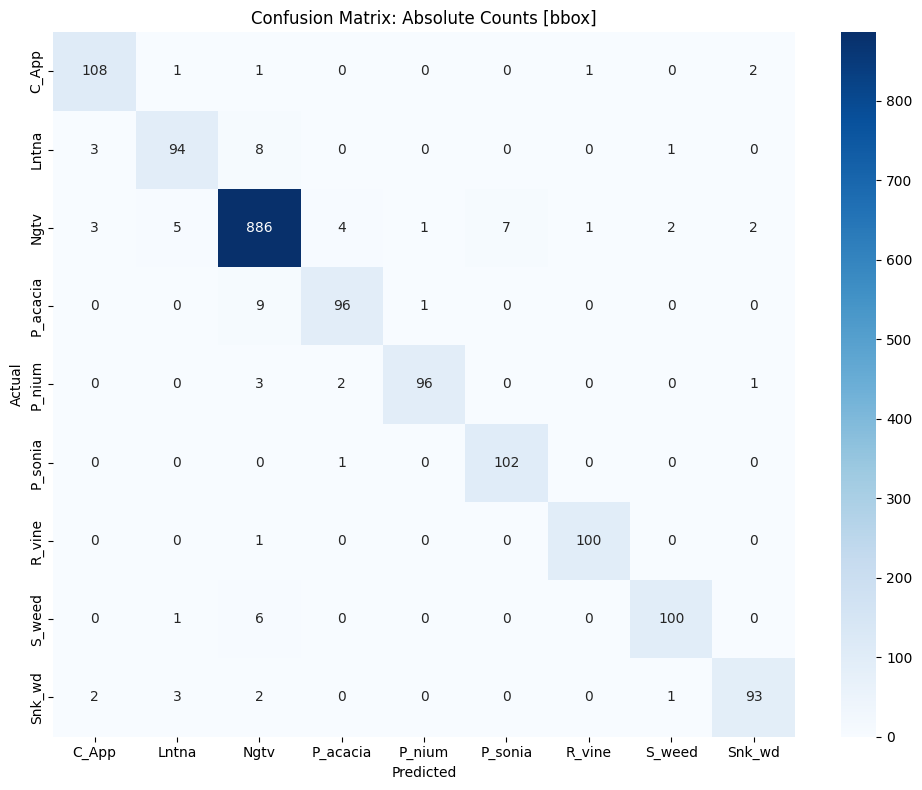

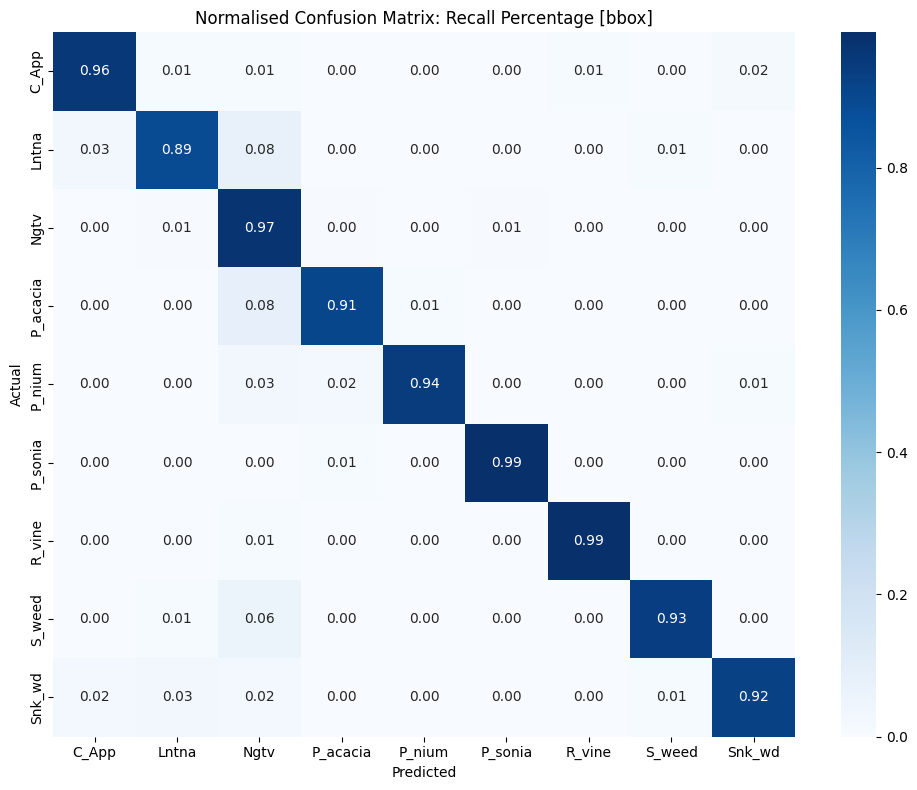


⏱ Pipeline A runtime: 7.20 hours


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# 12. MAIN

RESUME = False
run_start = time.time()
results_summary = {}

# PIPELINE A: BBOX

print("\n" + "="*60)
print("PIPELINE A: ANNOTATED DATASET (with bounding box)")
print("="*60)

bbox_train_dir = os.path.join(CONFIG["bbox_dir"], "train")
bbox_valid_dir = os.path.join(CONFIG["bbox_dir"], "valid")
bbox_test_dir  = os.path.join(CONFIG["bbox_dir"], "test")

bbox_class_to_idx, bbox_idx_to_class = build_bbox_class_map(bbox_train_dir)
CONFIG["num_classes"] = len(bbox_class_to_idx)

bbox_train = AnnotatedDataset(bbox_train_dir, bbox_class_to_idx,
                              transform=train_transforms)
bbox_valid = AnnotatedDataset(bbox_valid_dir, bbox_class_to_idx,
                              transform=train_transforms)
bbox_test  = AnnotatedDataset(bbox_test_dir,  bbox_class_to_idx,
                              transform=val_transforms)

bbox_combined        = ConcatDataset([bbox_train, bbox_valid])
bbox_combined_labels = ([s[1] for s in bbox_train.samples] +
                        [s[1] for s in bbox_valid.samples])

print(f"Train+Valid: {len(bbox_combined)} | Test: {len(bbox_test)}")

bbox_best_params = run_hyperparameter_tuning(bbox_combined, bbox_combined_labels)
bbox_fold_results, bbox_best_model = run_cross_validation(
    bbox_combined, bbox_combined_labels, bbox_best_params, tag="bbox")

print("\n=== CROSS VALIDATION SUMMARY [bbox] ===")
accs = [r["accuracy"] for r in bbox_fold_results]
f1s  = [r["f1"]       for r in bbox_fold_results]
for r in bbox_fold_results:
    print(f"  Fold {r['fold']}: Acc={r['accuracy']:.4f} | F1={r['f1']:.4f}")
print(f"  Mean Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"  Mean Macro F1 : {np.mean(f1s):.4f}  ± {np.std(f1s):.4f}")

results_summary["bbox"] = run_evaluation(
    bbox_best_model, bbox_test, bbox_idx_to_class, tag="bbox")

total_time = time.time() - run_start
print(f"\n⏱ Pipeline A runtime: {total_time/3600:.2f} hours")

from google.colab import files
import glob
for f in glob.glob("*bbox*"):
    files.download(f)


PIPELINE B: NON-ANNOTATED DATASET (no bounding box)


[I 2026-04-16 09:21:18,212] A new study created in memory with name: no-name-092b4dd0-0156-478e-905b-2034d74569e2


[Non-Annotated] Loaded 14007 images from /content/Project/train/train_labels.csv
[Non-Annotated] Loaded 3502 images from /content/Project/test/test_labels.csv
Train: 14007 | Test: 3502
✓ Images loaded successfully

=== HYPERPARAMETER TUNING (Optuna) ===
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 109MB/s]


  Epoch 01/10 | Train Loss: 0.8084 Acc: 0.7335 | Val Loss: 0.4324 Acc: 0.8508 F1: 0.8171
  ✓ Checkpoint saved → checkpoint_optuna_fold0.pth


...

  Epoch 12/15 | Train Loss: 0.1053 Acc: 0.9631 | Val Loss: 0.1618 Acc: 0.9507 F1: 0.9393
  ✓ Checkpoint saved → checkpoint_nobbox_fold5.pth


  Epoch 13/15 | Train Loss: 0.0914 Acc: 0.9677 | Val Loss: 0.1540 Acc: 0.9564 F1: 0.9465
  ✓ Checkpoint saved → checkpoint_nobbox_fold5.pth


  Epoch 14/15 | Train Loss: 0.0901 Acc: 0.9690 | Val Loss: 0.1494 Acc: 0.9547 F1: 0.9427


  Epoch 15/15 | Train Loss: 0.0746 Acc: 0.9751 | Val Loss: 0.1527 Acc: 0.9543 F1: 0.9420
  ⏱ Fold runtime: 20.2 minutes


  Fold 5 → Acc: 0.9564 | Macro F1: 0.9465

=== CROSS VALIDATION SUMMARY [nobbox] ===
  Fold 1: Acc=0.9529 | F1=0.9416
  Fold 2: Acc=0.9554 | F1=0.9430
  Fold 3: Acc=0.9472 | F1=0.9326
  Fold 4: Acc=0.9529 | F1=0.9396
  Fold 5: Acc=0.9564 | F1=0.9465
  Mean Accuracy : 0.9530 ± 0.0032
  Mean Macro F1 : 0.9406  ± 0.0046

=== FINAL TEST SET EVALUATION [nobbox] ===
Final Accuracy  : 0.9532
Macro Precision : 0.9378
Macro Recall    : 0.9428
Macro F1 Score  : 0.9401

--- Detailed Classification Report ---

                precision    recall  f1-score   support

  Chinee apple       0.90      0.90      0.90       219
       Lantana       0.94      0.94      0.94       211
   Parkinsonia       0.92      0.98      0.95       211
    Parthenium       0.92      0.95      0.94       196
Prickly acacia       0.94      0.91      0.93       217
   Rubber vine       0.96      0.97      0.97       223
     Siam weed       0.97      0.98      0.97       215
    Snake weed       0.91      0.88      0.89  

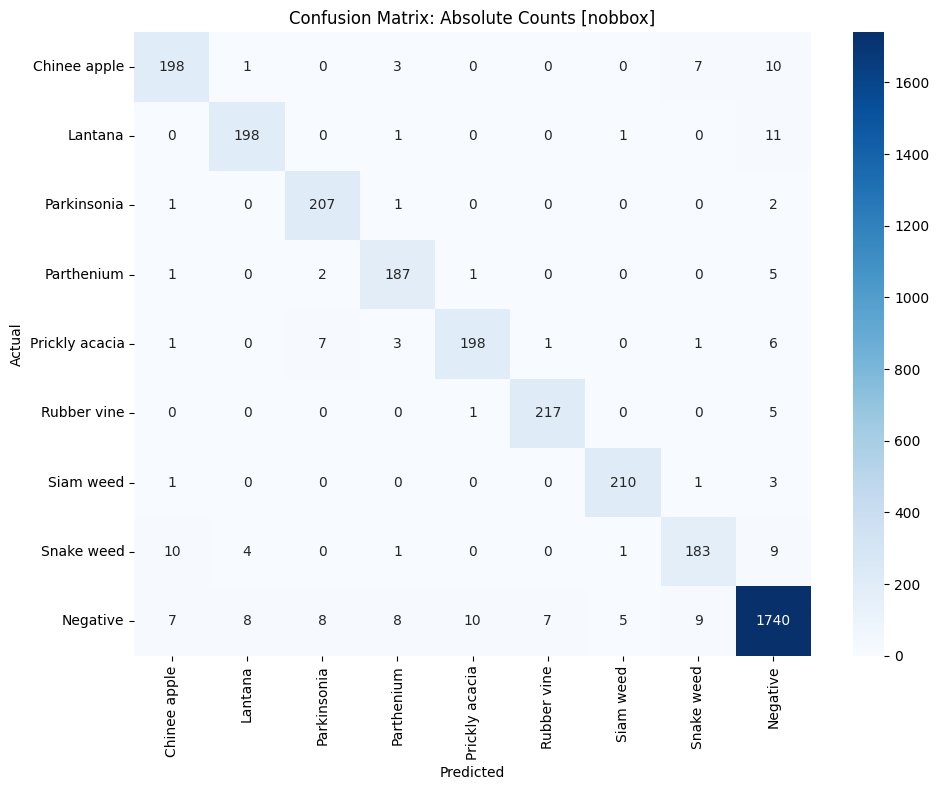

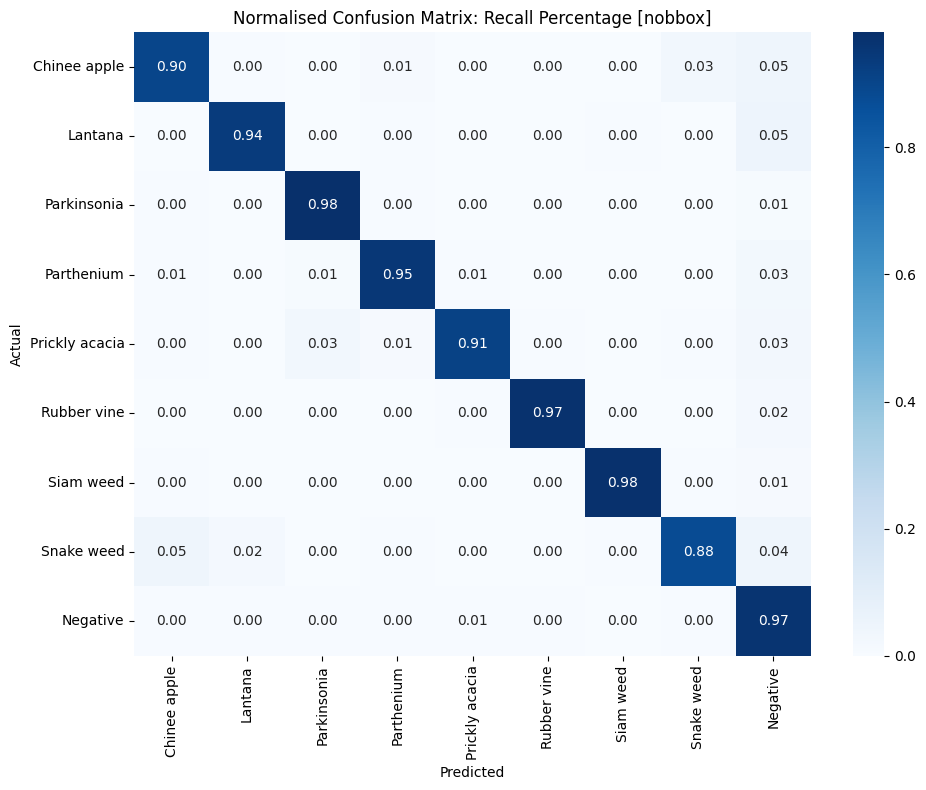

NameError: name 'results_summary' is not defined

In [5]:
# PIPELINE B: NO BBOX

RESUME = False

CONFIG["nobbox_train_dir"] = "/content/Project/train/images/"
CONFIG["nobbox_test_dir"]  = "/content/Project/test/images/"

run_start = time.time()

print("\n" + "="*60)
print("PIPELINE B: NON-ANNOTATED DATASET (no bounding box)")
print("="*60)

nobbox_train = NonAnnotatedDataset(CONFIG["nobbox_train_dir"],
                                   CONFIG["nobbox_train_csv"],
                                   transform=train_transforms)
nobbox_test  = NonAnnotatedDataset(CONFIG["nobbox_test_dir"],
                                   CONFIG["nobbox_test_csv"],
                                   transform=val_transforms)

nobbox_idx_to_class  = nobbox_train.idx_to_class
nobbox_train_labels  = [s[1] for s in nobbox_train.samples]
CONFIG["num_classes"] = len(nobbox_idx_to_class)

print(f"Train: {len(nobbox_train)} | Test: {len(nobbox_test)}")

assert len(nobbox_train) > 0, "ERROR: No training images found!"
assert len(nobbox_test)  > 0, "ERROR: No test images found!"
print("✓ Images loaded successfully")

nobbox_best_params = run_hyperparameter_tuning(nobbox_train, nobbox_train_labels)
nobbox_fold_results, nobbox_best_model = run_cross_validation(
    nobbox_train, nobbox_train_labels, nobbox_best_params, tag="nobbox")

print("\n=== CROSS VALIDATION SUMMARY [nobbox] ===")
accs = [r["accuracy"] for r in nobbox_fold_results]
f1s  = [r["f1"]       for r in nobbox_fold_results]
for r in nobbox_fold_results:
    print(f"  Fold {r['fold']}: Acc={r['accuracy']:.4f} | F1={r['f1']:.4f}")
print(f"  Mean Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"  Mean Macro F1 : {np.mean(f1s):.4f}  ± {np.std(f1s):.4f}")

results_summary["nobbox"] = run_evaluation(
    nobbox_best_model, nobbox_test, nobbox_idx_to_class, tag="nobbox")

total_time = time.time() - run_start
print(f"\n⏱ Pipeline B runtime: {total_time/3600:.2f} hours")

from google.colab import files
import glob
for f in glob.glob("*nobbox*"):
    files.download(f)